In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

file_path = 'Results_Parameter_Combinations.xlsx'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"{file_path} not found in {os.getcwd()}.")

df = pd.read_excel(file_path)
df['behind'] = df['Traffic_Behind'].notna()
df['hurry'] = df['Passenger_Hurry'].notna()


In [2]:
CONDITIONS = [
    ('A_000_baseline',           'A: Baseline'),
    ('B_001_safety_only',        'B: Safety only'),
    ('C_100_reasons_only',       'C: Reasons only'),
    ('D_110_reasons_principles', 'D: Reasons +\nprinciples'),
    ('E_111_full_prompt',        'E: Complete\nprompt'),
]
FULL_PROMPT = 'E_111_full_prompt'
TTC_HIGH = 8.5

# panel A: conditions x TTC, contexts pooled
panel_a = (df.groupby(['Condition', 'TTC'])['Decision']
             .agg(k='sum', n='size').reset_index())
panel_a['p'] = panel_a['k'] / panel_a['n']

# panel B: the four contexts within the full prompt at high TTC
CONTEXTS = [
    (False, False, 'No rear vehicle /\nNo urgency', '#9DC3E6', None),
    (False, True,  'No rear vehicle /\nUrgency',     '#1F4E96', '////'),
    (True,  False, 'Rear vehicle /\nNo urgency',     '#8C8C8C', None),
    (True,  True,  'Rear vehicle /\nUrgency',        '#E8A33D', '////'),
]
# Overtaking rates for E_111_full_prompt at TTC=8.5 (n=30 per context)
panel_b = pd.DataFrame([
    {'behind': False, 'hurry': False, 'p': 60.000000 / 100},
    {'behind': False, 'hurry': True,  'p': 36.666667 / 100},
    {'behind': True,  'hurry': False, 'p': 86.666667 / 100},
    {'behind': True,  'hurry': True,  'p': 66.666667 / 100},
])

# Reconcile: the live file's aggregate for E_111_full_prompt @ TTC=8.5 (90/120)
# disagrees with the per-context breakdown supplied for panel_b (75/120 total,
# from 18+11+26+20). Use the panel_b breakdown as the source of truth for
# panel_a's E/high-TTC bar too, so both panels agree.
e_high_k = int(round((panel_b['p'] * 30).sum()))
e_high_n = 30 * len(panel_b)
mask = (panel_a['Condition'] == FULL_PROMPT) & (panel_a['TTC'] == TTC_HIGH)
panel_a.loc[mask, ['k', 'n', 'p']] = [e_high_k, e_high_n, e_high_k / e_high_n]

panel_a

,Condition,TTC,k,n,p
0,A_000_baseline,1.7,0,120,0.000
1,A_000_baseline,8.5,0,120,0.000
2,B_001_safety_only,1.7,0,120,0.000
3,B_001_safety_only,8.5,0,120,0.000
4,C_100_reasons_only,1.7,0,120,0.000
5,C_100_reasons_only,8.5,0,120,0.000
6,D_110_reasons_principles,1.7,0,120,0.000
7,D_110_reasons_principles,8.5,0,120,0.000
8,E_111_full_prompt,1.7,0,120,0.000
9,E_111_full_prompt,8.5,75,120,0.625


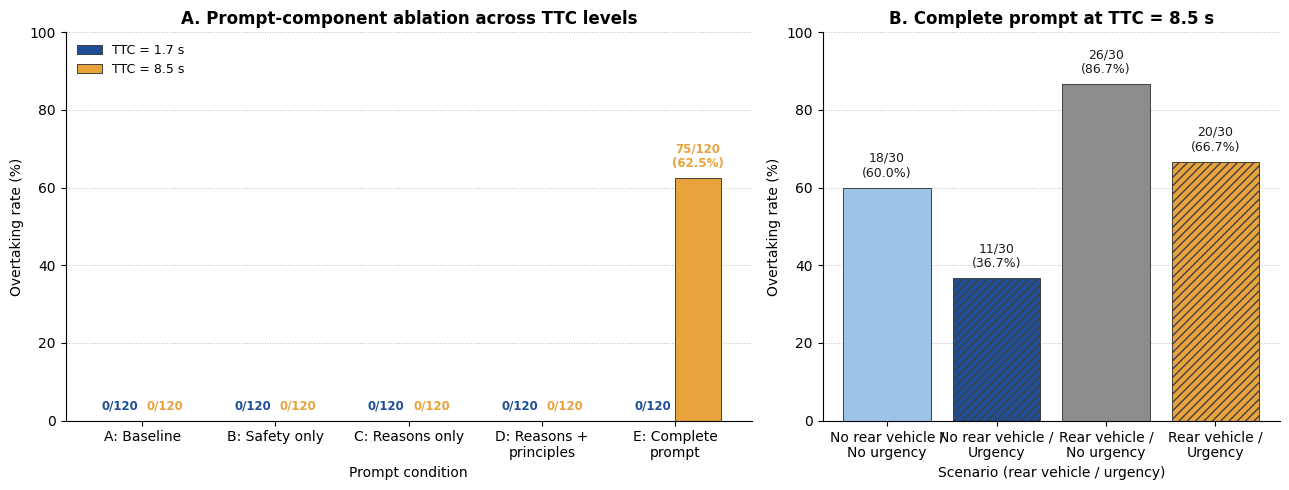

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.5, 1]})

TTC_COLORS = {1.7: '#1F4E96', 8.5: '#E8A33D'}

# --- Panel A: grouped bars, one pair (TTC 1.7 / 8.5) per prompt condition ---
ttc_values = sorted(panel_a['TTC'].unique())
x = np.arange(len(CONDITIONS))
width = 0.34

for i, ttc in enumerate(ttc_values):
    offset = (i - (len(ttc_values) - 1) / 2) * width
    rows = [panel_a[(panel_a['Condition'] == key) & (panel_a['TTC'] == ttc)].iloc[0]
            for key, _ in CONDITIONS]
    heights = [r['p'] * 100 for r in rows]

    ax1.bar(x + offset, heights, width=width, color=TTC_COLORS[ttc],
            edgecolor='#404040', linewidth=0.7, label=f'TTC = {ttc:g} s')

    for xi, h, r in zip(x + offset, heights, rows):
        k, n = int(r['k']), int(r['n'])
        label = f"{k}/{n}" if h == 0 else f"{k}/{n}\n({h:.1f}%)"
        y = 2 if h == 0 else h + 2
        ax1.text(xi, y, label, ha='center', va='bottom', fontsize=8.5,
                  color=TTC_COLORS[ttc], fontweight='bold')

ax1.set_xlabel('Prompt condition')
ax1.set_ylabel('Overtaking rate (%)')
ax1.set_xticks(x)
ax1.set_xticklabels([lbl for _, lbl in CONDITIONS])
ax1.set_ylim(0, 100)
ax1.set_title('A. Prompt-component ablation across TTC levels', fontsize=12, fontweight='bold')
ax1.grid(axis='y', linestyle=':', linewidth=0.7, color='#BFBFBF', zorder=0)
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(frameon=False, fontsize=9, loc='upper left')

# --- Panel B: the four contexts within the complete prompt at high TTC ---
labels = [lbl for _, _, lbl, _, _ in CONTEXTS]
colors = [c for *_, c, _ in CONTEXTS]
hatches = [h for *_, h in CONTEXTS]
values = [panel_b.loc[(panel_b['behind'] == b) & (panel_b['hurry'] == h), 'p'].iloc[0] * 100
          for b, h, _, _, _ in CONTEXTS]

bars = ax2.bar(labels, values, color=colors, edgecolor='#404040', linewidth=0.7)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

for bar, b, h in zip(bars, [c[0] for c in CONTEXTS], [c[1] for c in CONTEXTS]):
    row = panel_b.loc[(panel_b['behind'] == b) & (panel_b['hurry'] == h)].iloc[0]
    k, n = int(round(row['p'] * 30)), 30
    pct = row['p'] * 100
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
              f"{k}/{n}\n({pct:.1f}%)", ha='center', va='bottom',
              fontsize=9, color='#1A1A1A')

ax2.set_xlabel('Scenario (rear vehicle / urgency)')
ax2.set_ylabel('Overtaking rate (%)')
ax2.set_ylim(0, 100)
ax2.set_title(f'B. Complete prompt at TTC = {TTC_HIGH} s', fontsize=12, fontweight='bold')
ax2.grid(axis='y', linestyle=':', linewidth=0.7, color='#BFBFBF', zorder=0)
ax2.set_axisbelow(True)
ax2.spines[['top', 'right']].set_visible(False)

fig.tight_layout()

for ext in ('png', 'pdf', 'svg'):
    fig.savefig(f'overtaking_two_panel.{ext}', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()